In [1]:
# 패키지 설치 (arch는 GARCH용)
!pip -q install arch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from arch import arch_model
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [2]:
# 업로드한 파일 경로
REITS_RAW_PATH = "../../data/raw/리츠 22-24 csv 형식 합본.csv"
PF_RAW_PATH    = "../../data/raw/포트폴리오 22-24 csv 형식 합본.csv"

def zero_pad_krx(x):
    try:
        xi = int(float(x))
        return f"{xi:06d}"
    except Exception:
        return str(x)

def clean_wide_prices(path_in):
    df = pd.read_csv(path_in)
    # 1) 날짜
    if "Date" not in df.columns:
        raise ValueError("날짜 열 'Date'가 필요합니다.")
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # 2) 불필요 열 제거
    drop_cols = [c for c in df.columns if c.startswith("Unnamed")]
    df = df.drop(columns=drop_cols)

    # 3) 가격/티커 쌍 찾기
    close_cols = [c for c in df.columns if c.startswith("Close")]
    tick_cols  = [c for c in df.columns if c.startswith("ticker")]
    if len(close_cols) != len(tick_cols):
        raise ValueError(f"Close({len(close_cols)})와 ticker({len(tick_cols)}) 개수 불일치")

    # 4) ticker 열 고정 + 6자리 0패딩
    for tc in tick_cols:
        mode_val = df[tc].dropna().mode()
        if len(mode_val) > 0:
            df[tc] = mode_val.iloc[0]
        df[tc] = df[tc].map(zero_pad_krx)

    # 5) 와이드 → 롱
    out_list = []
    for ccol, tcol in zip(close_cols, tick_cols):
        temp = df[["Date", ccol, tcol]].rename(columns={"Date":"date", ccol:"close", tcol:"ticker"})
        out_list.append(temp)
    out = pd.concat(out_list, ignore_index=True).dropna(subset=["close"])

    # 6) 정리
    out["date"] = pd.to_datetime(out["date"]).dt.strftime("%Y-%m-%d")
    out = out.sort_values(["ticker","date"]).reset_index(drop=True)
    return out

reits_prices = clean_wide_prices(REITS_RAW_PATH)
pf_prices    = clean_wide_prices(PF_RAW_PATH)

print("REITs sample:")
display(reits_prices.head())
print("PF sample:")
display(pf_prices.head())


REITs sample:


,date,close,ticker
0,2022-01-03,8020,088260
1,2022-01-04,8010,088260
2,2022-01-05,8030,088260
3,2022-01-06,8030,088260
4,2022-01-07,8000,088260


PF sample:


,date,close,ticker
0,2022-01-03,128500,000660
1,2022-01-04,128500,000660
2,2022-01-05,125500,000660
3,2022-01-06,125000,000660
4,2022-01-07,127000,000660


In [3]:
# ret = 수익률 변환
def compute_simple_returns(df_long):
    df = df_long.copy()
    df = df.sort_values(["ticker","date"])
    df["date"] = pd.to_datetime(df["date"])
    df["ret"] = df.groupby("ticker")["close"].pct_change()
    df = df.dropna(subset=["ret"]).reset_index(drop=True)
    return df

reits_ret = compute_simple_returns(reits_prices)
pf_ret    = compute_simple_returns(pf_prices)

print("REITs returns:")
display(reits_ret.head())
print("PF returns:")
display(pf_ret.head())

REITs returns:


,date,close,ticker,ret
0,2022-01-04,8010,088260,-0.001247
1,2022-01-05,8030,088260,0.002497
2,2022-01-06,8030,088260,0.000000
3,2022-01-07,8000,088260,-0.003736
4,2022-01-10,8010,088260,0.001250


PF returns:


,date,close,ticker,ret
0,2022-01-04,128500,000660,0.000000
1,2022-01-05,125500,000660,-0.023346
2,2022-01-06,125000,000660,-0.003984
3,2022-01-07,127000,000660,0.016000
4,2022-01-10,124500,000660,-0.019685


In [4]:
# 개인 포트폴리오 균등 포트폴리오 수익률 계산

pf5 = ["005930","005380","000660","035720","035420"]

ret_wide_pf = pf_ret.pivot(index="date", columns="ticker", values="ret")
# 5종 모두 데이터가 있는 날짜만
ret_wide_pf = ret_wide_pf[pf5].dropna(how="any")
ret_wide_pf["PF"] = ret_wide_pf.mean(axis=1)

pf_series = ret_wide_pf["PF"].copy()
pf_series.index = pd.to_datetime(pf_series.index)
pf_series.name = "pf_ret"

# 1시차 -> GARCH-M 모형에서 필요한 이전일 수익률
pf_lag1 = pf_series.shift(1).dropna()
print("PF ret sample:")
display(pf_series.head())

PF ret sample:


date
2022-01-04   -0.011046
2022-01-05   -0.021147
2022-01-06   -0.021343
2022-01-07    0.007480
2022-01-10   -0.018395
Name: pf_ret, dtype: float64

In [5]:
# 공통 거래일이랑 리츠 겹치는 거 찾은 건데 사실 데이터 정리할 때 다 해놔서 할 필요는 없긴 함

ret_wide_reits = reits_ret.pivot(index="date", columns="ticker", values="ret")
ret_wide_reits.index = pd.to_datetime(ret_wide_reits.index)

# PF와 공통 날짜
common_dates = ret_wide_reits.index.intersection(pf_lag1.index)
ret_wide_reits = ret_wide_reits.loc[common_dates]
pf_lag1 = pf_lag1.loc[common_dates]

reits_list = list(ret_wide_reits.columns)
print(f"리츠 종목 수: {len(reits_list)}")
print("공통 시작~끝:", common_dates.min().date(), "~", common_dates.max().date())

리츠 종목 수: 18
공통 시작~끝: 2022-01-05 ~ 2024-12-30


In [6]:
# 변동성 측정 -> GARCH 모델의 조건부 분산 추정 -> Exponentially Weighted Moving Average 방법으로 리츠의 시간에 따라 변하는 변동성 σₜ (risk level) 측정
# GARCH-M => rREIT,t​=α+βrPF,t−1​+δσt​+εt​ r_REIT,t → 오늘 리츠의 수익률 / r_PF,t−1 → 전날 개인 포트폴리오 수익률 / σ_t → 그날의 변동성 (EWMA or GARCH로 추정한 위험 수준) / α, β, δ → 우리가 알고 싶은 계수들
# 아래로 쭉 가면서 하나씩 풀어갈 거임

def ewma_sigma(series, lam=0.94):
    # series: 리턴 시계열(pd.Series)
    sq = series**2
    ew = sq.ewm(alpha=(1-lam)).mean()
    return np.sqrt(ew)

# 예시: 첫 번째 리츠의 sigma_t

# σₜ가 크다 → 리츠 수익률이 불안정 (시장 불안정) / σₜ가 작다 → 리츠 가격이 안정적 / -> 여기 나온 σₜ를 in-Mean 회귀의 한 변수로 넣어 리츠의 평균수익률이 그날의 변동성(위험 수준)에 따라 달라지는 지 검증 가능

example_reit = reits_list[0]
sigma_ewma = ewma_sigma(ret_wide_reits[example_reit])
display(sigma_ewma.to_frame("sigma_ewma").head())

,sigma_ewma
date,
2022-01-05,0.002497
2022-01-06,0.001738
2022-01-07,0.002626
2022-01-10,0.002331
2022-01-11,0.002136


In [7]:
# GARCH(1,1) 모델 이용해서 리츠 수익률의 시간에 따라 변하는 변동성(σₜ)을 추정하는 함수 -> GARCH를 사용하는 큰 이유 중 하나로 이 σₜ가 과거의 충격과 연결돼 위험이 축적되거나 줄어드는 과정을 반영함

def garch_sigma(series):
    # series: 리턴 시계열(pd.Series)
    # 평균은 0, 분산은 GARCH(1,1)로 추정 → 조건부 sigma_t 반환
    am = arch_model(series.dropna()*100, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
    res = am.fit(disp="off")
    sigma_t = res.conditional_volatility / 100.0  # % 스케일 되돌림
    sigma_t.name = "sigma_garch"
    return sigma_t

sigma_garch = garch_sigma(ret_wide_reits[example_reit])
display(sigma_garch.head())

date
2022-01-05   0.003458
2022-01-06   0.003677
2022-01-07   0.003794
2022-01-10   0.004049
2022-01-11   0.004137
Name: sigma_garch, dtype: float64

In [8]:
# 아까 나왔던 rREIT,t​=α+βrPF,t−1​+δσt​+εt​ 이 식을 회귀로 추정하는 단계

import statsmodels.api as sm

def inmean_regression(r_reit, r_pf_lag1, sigma_t):
    # 세 시계열 공통 날짜 맞추기
    df = pd.concat([r_reit, r_pf_lag1, sigma_t], axis=1, join="inner").dropna()
    df.columns = ["r_reit", "r_pf_lag1", "sigma_t"]
    X = sm.add_constant(df[["r_pf_lag1", "sigma_t"]])
    y = df["r_reit"]
    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":1})  # 약한 자기상관 보정 -> 금융 시계열은 자기상관과 이분산이 심하니까 일반 회귀표준오차로 하면 t값이 왜곡됨
    return res

# EX: 첫 번째 리츠, GARCH 시그마 사용
reit = reits_list[0]
sigma = garch_sigma(ret_wide_reits[reit])  # 또는 ewma_sigma(...)
res = inmean_regression(ret_wide_reits[reit], pf_lag1, sigma)
print(reit, "회귀 요약:")
print(res.summary().tables[1])

088260 회귀 요약:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.001     -0.626      0.531      -0.003       0.002
r_pf_lag1      0.0257      0.029      0.883      0.377      -0.031       0.083
sigma_t        0.0340      0.131      0.259      0.796      -0.224       0.292


In [9]:
# β,δ 이 두 계수를 전 종목(18개 리츠)에 대해 한 번에 계산해서 표로 정리

rows = []
for reit in reits_list:                                             # 한 종목씩 순회하면서 GARCH → 회귀 → 결과 수집
    # σ_t 선택(EWMA or GARCH). 속도를 원하면 EWMA로 변환
    sigma = garch_sigma(ret_wide_reits[reit])                       # 각 리츠의 일별 수익률을 GARCH(1,1)로 넣어 그날의 변동성 시계열(σₜ) 계산
    res = inmean_regression(ret_wide_reits[reit], pf_lag1, sigma)
    beta   = res.params.get("r_pf_lag1", np.nan)
    delta  = res.params.get("sigma_t", np.nan)
    t_beta = res.tvalues.get("r_pf_lag1", np.nan)                   # t값	-> 계수가 0이 아니라는 통계적 근거의 크기 / p값 -> t값이 0보다 클 확률 (0.05 이하 → 유의)
    p_beta = res.pvalues.get("r_pf_lag1", np.nan)
    t_del  = res.tvalues.get("sigma_t", np.nan)
    p_del  = res.pvalues.get("sigma_t", np.nan)
    rows.append([reit, beta, t_beta, p_beta, delta, t_del, p_del, res.rsquared])

beta_table = pd.DataFrame(rows, columns=["ticker","beta","t_beta","p_beta","delta","t_delta","p_delta","R2"])
beta_table = beta_table.sort_values("beta")
display(beta_table)

C:\Users\pmpm9\AppData\Local\Temp\ipykernel_31588\1274998075.py:7: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")


,ticker,beta,t_beta,p_beta,delta,t_delta,p_delta,R2
3,204210,-0.065444,-0.892499,0.372125,-0.070529,-0.498444,0.618171,0.002635
12,365550,0.021702,0.492572,0.622315,-0.460006,-1.261589,0.207097,0.005917
4,293940,0.025651,0.882657,0.377422,0.034046,0.259007,0.795630,0.001452
0,088260,0.025651,0.882657,0.377422,0.034046,0.259007,0.795630,0.001452
14,395400,0.027715,0.736383,0.461498,-0.049431,-0.446088,0.655534,0.001049
11,357250,0.036609,1.498313,0.134052,0.019176,0.152920,0.878461,0.003243
9,350520,0.045876,1.865835,0.062064,0.039528,0.211601,0.832418,0.005880
17,404990,0.049850,1.274738,0.202402,-0.090699,-0.474484,0.635155,0.003232
2,145270,0.052234,1.585611,0.112828,-0.074656,-0.769890,0.441365,0.005179
1,140910,0.053405,1.498858,0.133910,-0.021081,-0.368413,0.712565,0.002995


,w_reit,mean,std
0,0.000000,-0.000250,0.015087
1,0.010000,-0.000251,0.014953
2,0.020000,-0.000253,0.014820
3,0.030000,-0.000255,0.014688
4,0.040000,-0.000256,0.014557


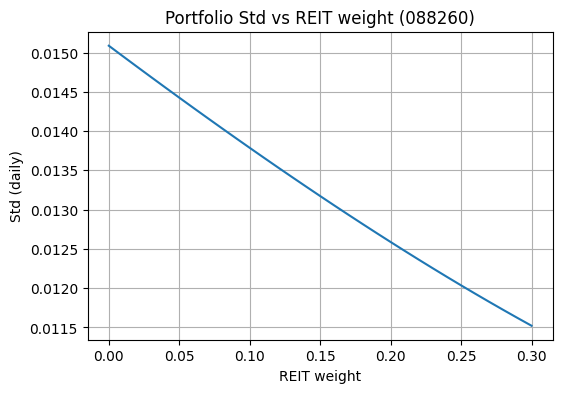

In [10]:
# 리츠 분산효과 시각화

def port_stats(pf, reit, w_grid=np.linspace(0, 0.3, 31)):
    # 공통 날짜
    idx = pf.index.intersection(reit.index)
    pf2 = pf.loc[idx]
    re2 = reit.loc[idx]
    # 결과 저장
    out = []
    for w in w_grid:
        r_mix = (1-w)*pf2 + w*re2
        out.append([w, r_mix.mean(), r_mix.std()])
    return pd.DataFrame(out, columns=["w_reit","mean","std"])

sample_reit = reits_list[0]
sim = port_stats(pf_series, ret_wide_reits[sample_reit])
display(sim.head())

plt.figure(figsize=(6,4))
plt.plot(sim["w_reit"], sim["std"])
plt.title(f"Portfolio Std vs REIT weight ({sample_reit})")
plt.xlabel("REIT weight")
plt.ylabel("Std (daily)")
plt.grid(True)
plt.show()